<a href="https://colab.research.google.com/github/DJCordhose/buch-machine-learning-notebooks/blob/master/kap11-drift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Drift Erkennung

Verändert sich die Verteilung von Ein- oder Ausabe?

In [1]:
import sys
IN_COLAB = 'google.colab' in sys.modules
IN_COLAB

False

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (20, 8)
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['axes.labelsize'] = 16

In [3]:
import seaborn as sns
sns.__version__

'0.13.2'

In [4]:
if IN_COLAB:
  !pip install -q "evidently>=0.7,<0.8"


In [5]:
import evidently
evidently.__version__

'0.7.21'

In [6]:
import numpy as np
import pandas as pd
import evidently
from evidently import Report
from evidently.presets import DataDriftPreset
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance


# Aktuelle und ursprüngliche Trainings-Daten holen

Aktuelle Daten 3 Jahre nach Training

In [7]:
from pathlib import Path

def url_for_dataset(relative_path):
  if IN_COLAB:
    url = f'https://github.com/DJCordhose/ml-for-business/raw/main/datasets/insurance_prediction/{relative_path}.csv.gz'
  else:
    # Im Original lagen auch die Monatsdateien unter datasets/insurance_prediction/.
    # Lokal halten wir sie bewusst direkt unter ./monthly, weil es sich um laufend
    # hinzukommende Betriebsdaten handelt und nicht um die statische Referenzdatei.
    url = f'./datasets/insurance_prediction/{relative_path}.csv.gz'
  return url

In [8]:
# how many months after training?
iteration = 36 # final month in dataset, should have the biggest difference
# iteration = 12 # one year later, drift should starting to show

In [9]:
reference_dataset_url = url_for_dataset(f'reference')
current_dataset_url = url_for_dataset(f'monthly/month-{iteration}')

In [10]:
reference_dataset = pd.read_csv(reference_dataset_url, sep=';')
reference_dataset = reference_dataset.drop(
    ['risk', 'group', 'group_name', 'good_customer'],
    axis='columns'
)
reference_dataset.head()


,training,age,emergency_braking,braking_distance,power,milage
0,0,41.951100,0,40.933328,122.238329,98.509765
1,0,24.368286,1,44.797317,113.765298,46.324178
2,0,18.314649,1,41.587241,143.427269,76.862968
3,0,51.265254,1,47.266716,111.578133,102.697069
4,0,23.578861,0,42.835319,145.994235,63.690055


In [11]:
current_dataset = pd.read_csv(current_dataset_url, sep=';')
current_dataset = current_dataset.drop(
    ['risk', 'group', 'group_name', 'good_customer'],
    axis='columns'
)
current_dataset.head()


,training,age,emergency_braking,braking_distance,power,milage
0,0,45.700860,1,33.730669,118.306787,92.429050
1,0,53.091268,1,35.575746,168.151487,53.595707
2,1,41.989477,1,37.515860,104.683894,40.402020
3,0,41.792728,1,44.043184,143.531543,46.462029
4,1,28.679302,1,34.329172,85.439495,39.791829


# Target / Prediction

In [12]:

import numpy as np
import torch
import torch.nn as nn

torch.__version__


'2.12.0'

In [13]:
# Wir definieren hier dieselbe Modellarchitektur wie im Training.
# Das gespeicherte PyTorch-state_dict enthält nur die gelernten Parameter
# und Buffer, aber nicht die Python-Klassen des Modells.
# Deshalb muss die Architektur beim Laden bekannt sein, bevor wir mit
# load_state_dict() die trainierten Gewichte einsetzen.

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, x):
        return (x - self.mean) / self.std


class BinaryClassifier(nn.Module):
    def __init__(self, num_features, feature_mean, feature_std,
                 neurons_per_layer=100, dropout=0.7):
        super().__init__()

        self.network = nn.Sequential(
            Normalization(feature_mean, feature_std),

            nn.Linear(num_features, neurons_per_layer),
            nn.ReLU(),
            nn.BatchNorm1d(neurons_per_layer),
            nn.Dropout(dropout),

            nn.Linear(neurons_per_layer, neurons_per_layer),
            nn.ReLU(),
            nn.BatchNorm1d(neurons_per_layer),
            nn.Dropout(dropout),

            nn.Linear(neurons_per_layer, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(-1)


if IN_COLAB:
    !mkdir -p models
    url = "https://github.com/DJCordhose/buch-machine-learning-notebooks/raw/master/models/classifier-binary.pt"
    !wget -q -O models/classifier-binary.pt {url}

model_path = Path("models") / "classifier-binary.pt"

if not model_path.exists():
    raise FileNotFoundError(
        f"{model_path} nicht gefunden. Bitte zuerst kap10-train.ipynb ausführen "
        "oder classifier-binary.pt nach ./models kopieren."
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load(model_path, map_location=device)

model = BinaryClassifier(
    num_features=checkpoint["num_features"],
    feature_mean=torch.zeros(checkpoint["num_features"], dtype=torch.float32),
    feature_std=torch.ones(checkpoint["num_features"], dtype=torch.float32),
    neurons_per_layer=checkpoint["neurons_per_layer"],
    dropout=checkpoint["dropout"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

model


BinaryClassifier(
  (network): Sequential(
    (0): Normalization()
    (1): Linear(in_features=6, out_features=100, bias=True)
    (2): ReLU()
    (3): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): Dropout(p=0.7, inplace=False)
    (5): Linear(in_features=100, out_features=100, bias=True)
    (6): ReLU()
    (7): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): Dropout(p=0.7, inplace=False)
    (9): Linear(in_features=100, out_features=1, bias=True)
  )
)

In [14]:
# Ausführliche Modellbeschreibung ausgeben:
from torchinfo import summary

print( summary(
    model,
    input_size=(2, 6),
    col_names=("input_size", "output_size", "num_params", "mult_adds", "trainable"),
    row_settings=("depth", "var_names"),
    depth=3,
))

Layer (type (var_name):depth-idx)        Input Shape               Output Shape              Param #                   Mult-Adds                 Trainable
BinaryClassifier (BinaryClassifier)      [2, 6]                    [2]                       --                        --                        True
├─Sequential (network): 1-1              [2, 6]                    [2, 1]                    --                        --                        True
│    └─Normalization (0): 2-1            [2, 6]                    [2, 6]                    --                        --                        --
│    └─Linear (1): 2-2                   [2, 6]                    [2, 100]                  700                       1,400                     True
│    └─ReLU (2): 2-3                     [2, 100]                  [2, 100]                  --                        --                        --
│    └─BatchNorm1d (3): 2-4              [2, 100]                  [2, 100]                  200   

In [15]:
def prediction_name(value: int):
  names = ['BAD', 'GOOD']
  return names[value]

def predict_proba(X):
  # PyTorch trennt Training und Inferenz nicht automatisch über eine predict()-API.
  # eval() und no_grad() sind hier wichtig, weil Dropout und BatchNorm sonst wie im
  # Training arbeiten würden und die Drift-Auswertung instabil würde.
  
  model.eval()
  X_tensor = torch.tensor(X.values if hasattr(X, 'values') else X, dtype=torch.float32).to(device)
  with torch.no_grad():
    probabilities = torch.sigmoid(model(X_tensor))
  return probabilities.cpu().numpy()

def predict(X):
  threshold = .5
  y_pred = (predict_proba(X) > threshold).ravel().astype("int")
  return list(map(prediction_name, y_pred))


In [16]:
X = current_dataset
current_dataset_prediction = X.copy()
current_dataset_prediction['prediction'] = predict(X)
current_dataset_prediction.head()

,training,age,emergency_braking,braking_distance,power,milage,prediction
0,0,45.700860,1,33.730669,118.306787,92.429050,GOOD
1,0,53.091268,1,35.575746,168.151487,53.595707,BAD
2,1,41.989477,1,37.515860,104.683894,40.402020,GOOD
3,0,41.792728,1,44.043184,143.531543,46.462029,GOOD
4,1,28.679302,1,34.329172,85.439495,39.791829,GOOD


In [17]:
X = reference_dataset
reference_dataset_prediction = X.copy()
reference_dataset_prediction['prediction'] =  predict(X)
reference_dataset_prediction.head()

,training,age,emergency_braking,braking_distance,power,milage,prediction
0,0,41.951100,0,40.933328,122.238329,98.509765,BAD
1,0,24.368286,1,44.797317,113.765298,46.324178,BAD
2,0,18.314649,1,41.587241,143.427269,76.862968,BAD
3,0,51.265254,1,47.266716,111.578133,102.697069,BAD
4,0,23.578861,0,42.835319,145.994235,63.690055,BAD


# Welche Features driften?

In [18]:
categorical_columns = ['training', 'emergency_braking']
numerical_columns = ['age', 'braking_distance', 'power', 'milage']
prediction_column = 'prediction'

columns = categorical_columns + numerical_columns + [prediction_column]
drift_share = 0.5
columns


['training',
 'emergency_braking',
 'age',
 'braking_distance',
 'power',
 'milage',
 'prediction']

In [19]:
reference_for_drift = reference_dataset_prediction[columns].copy()
current_for_drift = current_dataset_prediction[columns].copy()

# Evidently 0.7.x leitet die Spaltentypen aus den Pandas-Datentypen ab.
# Die binären Features und die Modellvorhersage sollen als kategoriale Daten
# behandelt werden, nicht als numerische Messwerte.
for column in categorical_columns + [prediction_column]:
    reference_for_drift[column] = reference_for_drift[column].astype('category')
    current_for_drift[column]   = current_for_drift[column].astype('category')


In [20]:
report = Report([
    DataDriftPreset(
        columns=columns,
        drift_share=drift_share,
    )
])

result = report.run(
    current_data=current_for_drift,
    reference_data=reference_for_drift,
)

In [21]:
# Das Ergebnisobjekt ist weiterhin nützlich für den visuellen Report.
# Die programmatische Auswertung unten berechnen wir bewusst separat,
# weil die interne Ergebnisstruktur von Evidently zwischen Versionen wechseln kann.
result_dict = result.dict()
result_dict.keys()


dict_keys(['metrics', 'tests'])

In [22]:
# Programmatische Drift-Auswertung für Evidently 0.7.x.
# Wir berechnen die Werte explizit, anstatt interne Evidently-Strukturen
# wie drift_by_columns zu verwenden. Diese waren in älteren Versionen verfügbar,
# sind in 0.7.x aber nicht mehr stabil als öffentliche API nutzbar.

DRIFT_THRESHOLD = 0.1


def categorical_distribution(series, categories):
    return (
        series.astype(str)
        .value_counts(normalize=True)
        .reindex([str(category) for category in categories], fill_value=0.0)
        .to_numpy()
    )


def categorical_drift(reference_series, current_series):
    categories = sorted(set(reference_series.astype(str)) | set(current_series.astype(str)))
    reference_distribution = categorical_distribution(reference_series, categories)
    current_distribution = categorical_distribution(current_series, categories)
    return float(jensenshannon(reference_distribution, current_distribution))


def numerical_drift(reference_series, current_series):
    reference_values = reference_series.to_numpy(dtype=float)
    current_values = current_series.to_numpy(dtype=float)
    scale = np.std(reference_values)
    if scale == 0:
        scale = 1.0
    return float(wasserstein_distance(reference_values, current_values) / scale)


def drift_for_column(column):
    if column in categorical_columns + [prediction_column]:
        score = categorical_drift(reference_for_drift[column], current_for_drift[column])
        stattest_name = "Jensen-Shannon distance"
    else:
        score = numerical_drift(reference_for_drift[column], current_for_drift[column])
        stattest_name = "Wasserstein distance (normed)"

    return {
        "drift_score": score,
        "stattest_name": stattest_name,
        "drift_detected": score >= DRIFT_THRESHOLD,
    }


drift_by_columns = {
    column: drift_for_column(column)
    for column in columns
}

drift_by_columns


{'training': {'drift_score': 0.026168996995345667,
  'stattest_name': 'Jensen-Shannon distance',
  'drift_detected': False},
 'emergency_braking': {'drift_score': 0.431489050691815,
  'stattest_name': 'Jensen-Shannon distance',
  'drift_detected': True},
 'age': {'drift_score': 0.33634057577174653,
  'stattest_name': 'Wasserstein distance (normed)',
  'drift_detected': True},
 'braking_distance': {'drift_score': 0.07052872681963736,
  'stattest_name': 'Wasserstein distance (normed)',
  'drift_detected': False},
 'power': {'drift_score': 0.027969027840461604,
  'stattest_name': 'Wasserstein distance (normed)',
  'drift_detected': False},
 'milage': {'drift_score': 0.7140663279609665,
  'stattest_name': 'Wasserstein distance (normed)',
  'drift_detected': True},
 'prediction': {'drift_score': 0.10644915783449473,
  'stattest_name': 'Jensen-Shannon distance',
  'drift_detected': True}}

In [23]:
number_of_columns = len(columns)
number_of_columns


7

In [24]:
number_of_drifted_columns = sum(
    1 for drift in drift_by_columns.values()
    if drift["drift_detected"]
)
number_of_drifted_columns


4

In [25]:
share_of_drifted_columns = number_of_drifted_columns / number_of_columns
dataset_drift = share_of_drifted_columns >= drift_share
share_of_drifted_columns, dataset_drift


(0.5714285714285714, True)

In [26]:
# Für eine besser lesbare Ausgabe verwenden wir hier gerundete Werte.
for column in columns:
    drift = drift_by_columns[column]
    print(
        f'{column}: {drift["drift_score"]:.3f} ({drift["stattest_name"]})'
        f'{", drifted" if drift["drift_detected"] else ""}'
    )


training: 0.026 (Jensen-Shannon distance)
emergency_braking: 0.431 (Jensen-Shannon distance), drifted
age: 0.336 (Wasserstein distance (normed)), drifted
braking_distance: 0.071 (Wasserstein distance (normed))
power: 0.028 (Wasserstein distance (normed))
milage: 0.714 (Wasserstein distance (normed)), drifted
prediction: 0.106 (Jensen-Shannon distance), drifted


# Korrelationen im Vergleich

In [27]:
### jwl 16.04.2026: Hier wird 'milage' als 'miles' geschrieben: inkonsistent oder Absicht?
###                 Bestenfall vereinheitlichebn zu 'mileage'
features = ['training', 'age', 'emergency_braking', 'braking_distance', 'power', 'miles', 'risk', 'prediction']

def plot_correlation(df, ax, title):
    df_corr = df.drop(columns=["group", "group_name", "good_customer"])

    cm = df_corr.corr()

    hm = sns.heatmap(cm,
                     ax=ax,
                    cbar=True,
                    annot=True,
                    square=True,
                    cmap='RdBu',
                    center=0,
                    fmt='.2f',
                    yticklabels=features,
                    xticklabels=features)

    ax.set_title(title, y=1.02, fontsize=18);

In [28]:
import pandas as pd

threshold = .5

# Für die Korrelationen brauchen wir numerische Vorhersagen statt der Labelnamen BAD/GOOD.
# Deshalb verwenden wir hier dieselbe PyTorch-Inferenz wie oben, aber ohne Mapping auf Strings.

df_reference = pd.read_csv(url_for_dataset(f'reference'), delimiter=';')
df_reference["prediction"] = (predict_proba(reference_dataset) > threshold).ravel().astype("int")

df_iteration = pd.read_csv(url_for_dataset(f'monthly/month-{iteration}'), delimiter=';')
df_iteration["prediction"] = (predict_proba(current_dataset) > threshold).ravel().astype("int")


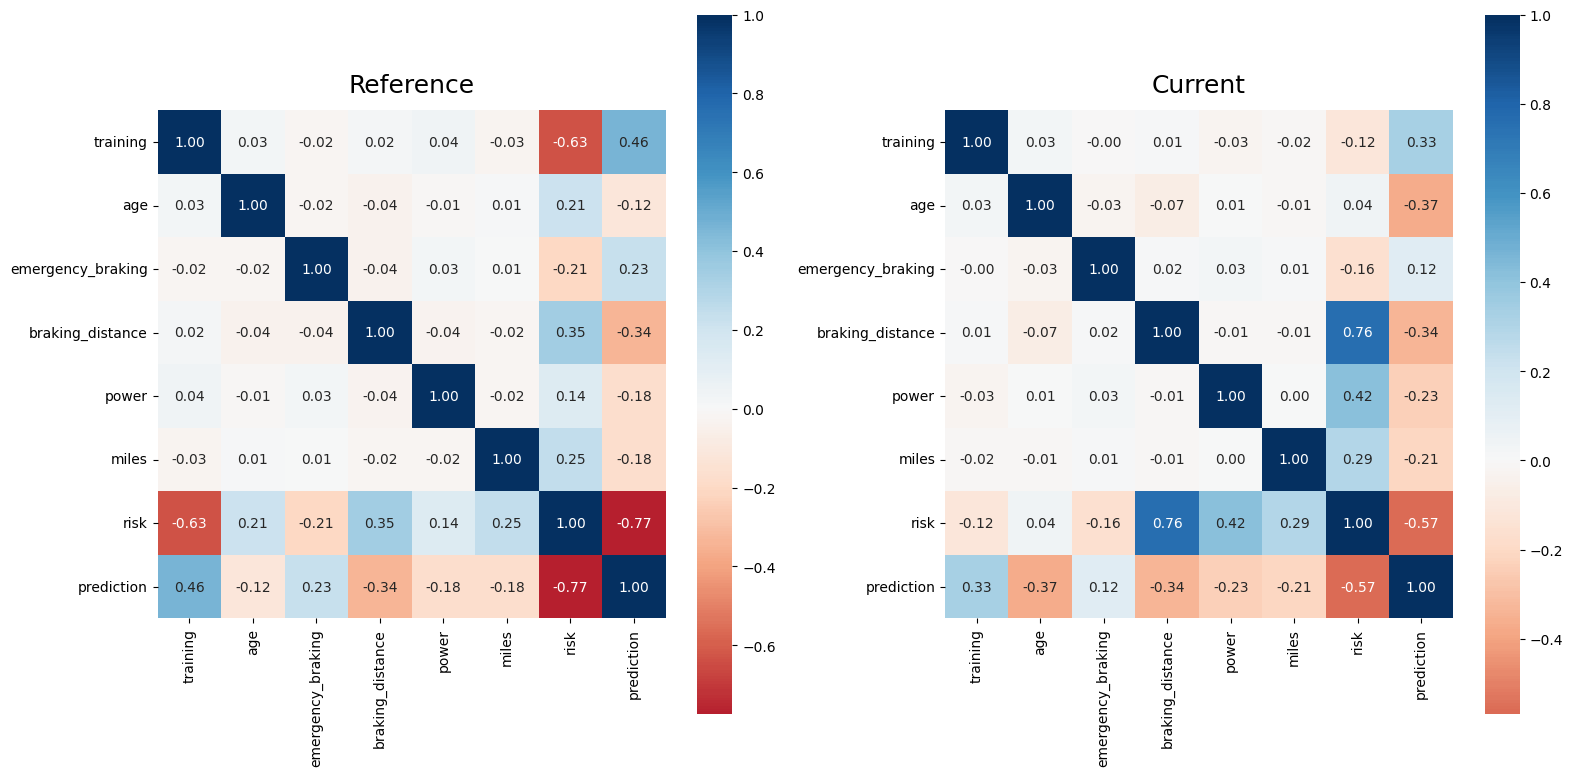

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

plot_correlation(df_reference, ax1, "Reference")
plot_correlation(df_iteration, ax2, "Current")
plt.tight_layout()


# Kompletter Report

In [30]:
df_iteration_X = df_iteration.drop(['risk', 'group', 'group_name', 'good_customer'], axis='columns')
df_reference_X = df_reference.drop(['risk', 'group', 'group_name', 'good_customer'], axis='columns')

In [31]:
report = Report([
   DataDriftPreset(),
])

result = report.run(
    current_data=df_iteration_X,
    reference_data=df_reference_X,
)
result


# Beobachtungen / Interpretation

* weniger schlechte Fahrer
* Die Gesellschaft altert
* Leute fahren weniger
* Die Fähigkeiten der Fahrer sind weniger wichtig
* Fast alle Fahrzeuge haben ein Notbremsystem


# Maßnahme

1. ~~Nichts tun~~
1. ~~Model EOL, Fallback auf Regelsystem~~
1. _Re-Train_
1. _Re-Engineer_
1. _Re-Calibrate_

*Im Detail*
* Neu-Trainieren mit dem neuesten Datensatz, aber
  * Nur noch Fahrzeuge mit Notbremssystem für das Training nutzen und
  *  Notbremssystem als nutzloses Feature aus dem Training herausnehmen
* Threshold für Akzeptanz als Kunde neu kalibrieren
* Einen höhreren Anteil an Versicherten wagen  